#   EDA: `prices`

**Descripción:** Historial de precios por juego en 5 monedas. Cada fila es un snapshot del precio de un juego en una fecha específica.

| Columna | Tipo | Descripción |
|---|---|---|
| `gameid` | int | ID del juego |
| `usd` | float | Precio en dólares estadounidenses |
| `eur` | float | Precio en euros |
| `gbp` | float | Precio en libras esterlinas |
| `jpy` | float | Precio en yenes japoneses |
| `rub` | float | Precio en rublos rusos |
| `date_acquired` | date | Fecha del snapshot |


## Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
ACCENT5 = '#c77dff'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

##  Carga y exploración inicial

In [2]:
df_raw = pd.read_csv('Datos/prices.csv')   
df_raw['date_acquired'] = pd.to_datetime(df_raw['date_acquired'], errors='coerce')

print(f"Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"Juegos únicos    : {df_raw['gameid'].nunique():,}")
print(f"Fechas únicas    : {df_raw['date_acquired'].nunique()}")
print(f"Rango temporal   : {df_raw['date_acquired'].min().date()} → {df_raw['date_acquired'].max().date()}")
print()
df_raw.head(5)

Shape: 4,414,273 filas × 7 columnas
Juegos únicos    : 98,465
Fechas únicas    : 45
Rango temporal   : 2024-11-28 → 2025-02-24



,gameid,usd,eur,gbp,jpy,rub,date_acquired
0,3281560,NaN,NaN,NaN,NaN,NaN,2024-11-28
1,3280930,NaN,NaN,NaN,NaN,NaN,2024-11-28
2,3280770,NaN,NaN,NaN,NaN,NaN,2024-11-28
3,3279790,NaN,NaN,NaN,NaN,NaN,2024-11-28
4,3278320,NaN,NaN,NaN,NaN,NaN,2024-11-28


In [3]:
print(df_raw.dtypes)
print()
df_raw.describe()

gameid                    int64
usd                     float64
eur                     float64
gbp                     float64
jpy                     float64
rub                     float64
date_acquired    datetime64[ns]
dtype: object



,gameid,usd,eur,gbp,jpy,rub,date_acquired
count,4.414273e+06,3.507125e+06,2.711187e+06,3.506089e+06,3.494300e+06,3.407982e+06,4414273
mean,1.609346e+06,8.144524e+00,8.189231e+00,6.623406e+00,9.127651e+02,2.824408e+02,2025-01-11 02:05:38.609050624
min,1.000000e+01,4.900000e-01,4.900000e-01,0.000000e+00,6.000000e+01,0.000000e+00,2024-11-28 00:00:00
25%,8.848300e+05,1.990000e+00,2.060000e+00,1.690000e+00,2.350000e+02,8.200000e+01,2024-12-20 00:00:00
50%,1.567990e+06,4.990000e+00,4.990000e+00,4.290000e+00,5.800000e+02,1.650000e+02,2025-01-11 00:00:00
75%,2.301920e+06,9.990000e+00,9.750000e+00,8.000000e+00,1.080000e+03,3.200000e+02,2025-02-02 00:00:00
max,3.441890e+06,9.999800e+02,9.990000e+02,9.990000e+02,1.979970e+05,1.000000e+05,2025-02-24 00:00:00
std,8.532575e+05,1.412204e+01,1.468652e+01,1.203188e+01,1.921089e+03,1.294842e+03,NaN


---
## Análisis y tratamiento de valores faltantes

### Diagnóstico 

| Columna | Nulos | % | Causa probable |
|---|---|---|---|
| `gameid` | 0 | 0% | Clave primaria — sin faltantes |
| `usd` | 907,148 | 20.6% | Juegos sin precio activo (free-to-play, no lanzados o retirados del catálogo) |
| `eur` | 1,703,086 | **38.6%** | Juegos no publicados o no disponibles en la región europea |
| `gbp` | 908,184 | 20.6% | Mismo patrón que USD |
| `jpy` | 919,973 | 20.8% | Similar a USD — diferencias regionales menores |
| `rub` | 1,006,291 | 22.8% | Ligeramente mayor — posiblemente afectado por restricciones regionales |
| `date_acquired` | 0 | 0% | Sin valores faltantes |

### Hallazgo clave: EUR tiene muchos más nulos
Existen 796,478 filas (22.7%) donde USD está presente pero EUR no, lo que sugiere juegos disponibles globalmente pero no publicados en la región europea. Esto refleja restricciones regionales del catálogo, no errores de datos.

### Hallazgo clave: juegos siempre sin precio
Se identifican 20,049 juegos (~20.4% de los juegos únicos) que nunca tienen precio USD en ningún snapshot. Probablemente corresponden a:
- juegos **free-to-play** (Steam no registra `$0`)
- juegos **pre-release**
- juegos **retirados del catálogo**

### Estabilidad temporal
El porcentaje de nulos en `usd` se mantiene muy estable entre 20.2% y 20.8% a lo largo de todos los snapshots (nov 2024 – feb 2025), lo que indica que el patrón de faltantes no depende del tiempo sino del tipo de juego.



In [4]:
currencies = ['usd', 'eur', 'gbp', 'jpy', 'rub']

miss_cnt = df_raw[currencies + ['date_acquired']].isnull().sum()
miss_pct = (df_raw[currencies + ['date_acquired']].isnull().mean() * 100).round(2)
print("Nulos por columna:")
display(pd.DataFrame({'count': miss_cnt, 'pct (%)': miss_pct}))
print()

has_usd_no_eur = (df_raw['usd'].notna() & df_raw['eur'].isna()).sum()
print(f"USD presente pero EUR ausente   : {has_usd_no_eur:,}  ({has_usd_no_eur/df_raw['usd'].notna().sum()*100:.1f}% de rows con USD)")
print()

never_priced = df_raw.groupby('gameid')['usd'].apply(lambda x: x.notna().sum() == 0)
print(f"Juegos SIEMPRE sin precio USD   : {never_priced.sum():,}  ({never_priced.mean()*100:.1f}% de juegos únicos)")
print(f"Juegos con AL MENOS 1 precio USD: {(~never_priced).sum():,}")
print()

print("% nulos en USD por fecha:")
display(df_raw.groupby('date_acquired')['usd'].apply(
    lambda x: f"{x.isna().mean()*100:.1f}%  (n={len(x):,})"
).rename('usd_null_%').to_frame())

Nulos por columna:


,count,pct (%)
usd,907148,20.55
eur,1703086,38.58
gbp,908184,20.57
jpy,919973,20.84
rub,1006291,22.80
date_acquired,0,0.00



USD presente pero EUR ausente   : 796,478  (22.7% de rows con USD)

Juegos SIEMPRE sin precio USD   : 20,049  (20.4% de juegos únicos)
Juegos con AL MENOS 1 precio USD: 78,416

% nulos en USD por fecha:


,usd_null_%
date_acquired,
2024-11-28,"20.2% (n=97,659)"
2024-11-30,"20.2% (n=97,659)"
2024-12-02,"20.3% (n=97,713)"
2024-12-04,"20.3% (n=97,713)"
2024-12-06,"20.3% (n=97,713)"
2024-12-08,"20.3% (n=97,713)"
2024-12-10,"20.3% (n=97,713)"
2024-12-12,"20.3% (n=97,713)"
2024-12-14,"20.4% (n=97,713)"


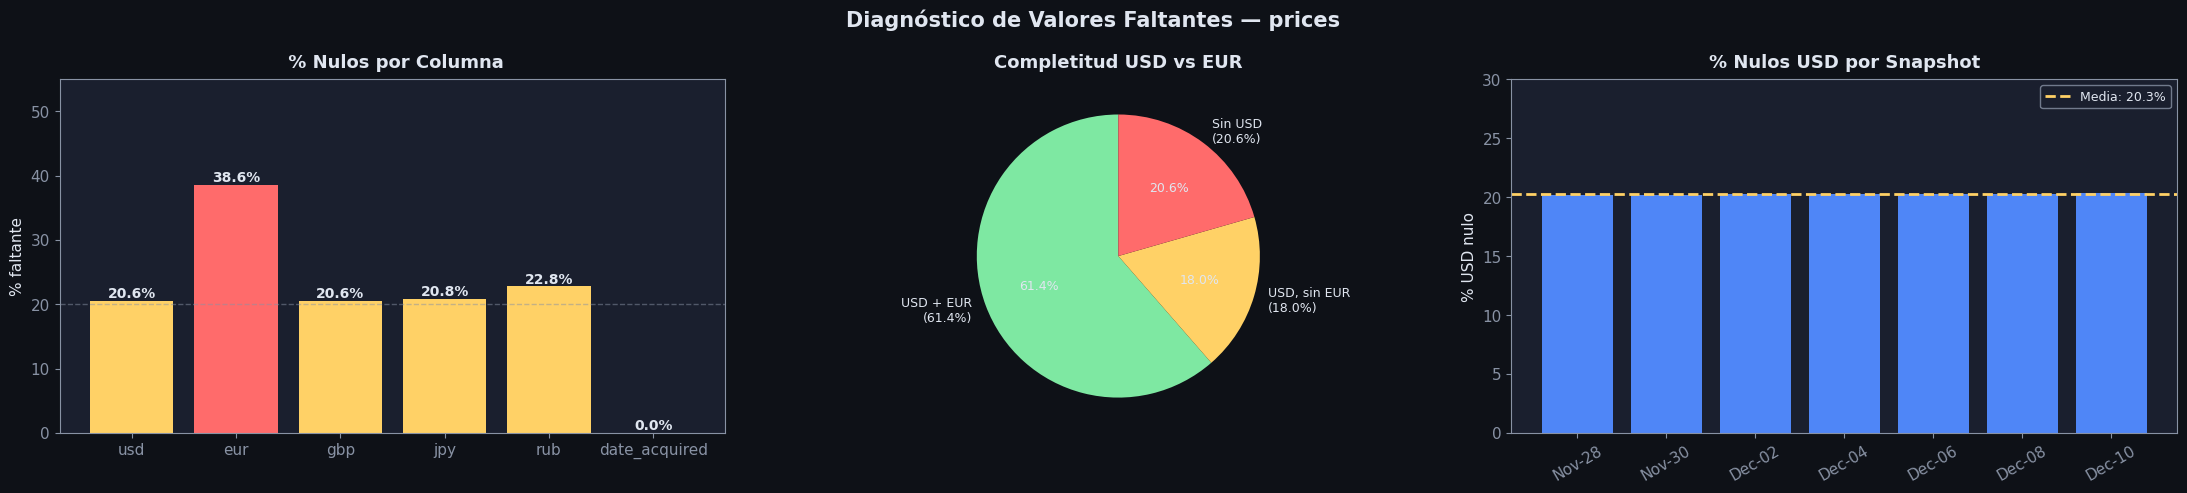

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de Valores Faltantes — prices', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
cols_show = currencies + ['date_acquired']
pct_vals  = miss_pct[cols_show].values
col_colors = [ACCENT3 if v > 30 else ACCENT4 if v > 15 else ACCENT1 for v in pct_vals]
bars = ax.bar(cols_show, pct_vals, color=col_colors)
for bar, val in zip(bars, pct_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, color=TEXT, fontweight='bold')
ax.set_ylabel('% faltante'); ax.set_ylim(0, 55)
ax.axhline(20, color=MUTED, linewidth=1, linestyle='--', alpha=0.5)
title_ax(ax, ' % Nulos por Columna')

ax = axes[1]
n_usd_eur    = (df_raw['usd'].notna() & df_raw['eur'].notna()).sum()
n_usd_no_eur = has_usd_no_eur
n_no_usd     = df_raw['usd'].isna().sum()
ax.pie([n_usd_eur, n_usd_no_eur, n_no_usd],
       labels=[f'USD + EUR\n({n_usd_eur/len(df_raw)*100:.1f}%)',
               f'USD, sin EUR\n({n_usd_no_eur/len(df_raw)*100:.1f}%)',
               f'Sin USD\n({n_no_usd/len(df_raw)*100:.1f}%)'],
       colors=[ACCENT2, ACCENT4, ACCENT3], startangle=90,
       textprops={'color': TEXT, 'fontsize': 9}, autopct='%1.1f%%')
title_ax(ax, 'Completitud USD vs EUR')

ax = axes[2]
null_by_date = df_raw.groupby('date_acquired')['usd'].apply(
    lambda x: x.isna().mean() * 100
).reset_index()
null_by_date.columns = ['date', 'pct_null']
null_by_date = null_by_date[null_by_date['date'] <= pd.Timestamp('2024-12-10')]
ax.bar(null_by_date['date'].dt.strftime('%b-%d'), null_by_date['pct_null'],
       color=ACCENT1)
ax.axhline(null_by_date['pct_null'].mean(), color=ACCENT4, linewidth=2,
           linestyle='--', label=f"Media: {null_by_date['pct_null'].mean():.1f}%")
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('% USD nulo'); ax.set_ylim(0, 30)
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '% Nulos USD por Snapshot')

plt.tight_layout()
plt.show()

In [6]:
df = df_raw.copy()

before = len(df)
df = df[df['date_acquired'].notna()].reset_index(drop=True)
print(f"Eliminadas por date_acquired nulo: {before - len(df)} filas")

CUTOFF = pd.Timestamp('2024-12-10')
anomalous = df[df['date_acquired'] > CUTOFF]
print(f"Filas con fecha anómala (>{CUTOFF.date()}): {len(anomalous)}")
df = df[df['date_acquired'] <= CUTOFF].reset_index(drop=True)

never_priced_ids = set(df.groupby('gameid')['usd'].apply(lambda x: x.notna().sum() == 0)
                       .pipe(lambda s: s[s].index.tolist()))
df['has_price'] = ~df['gameid'].isin(never_priced_ids)

df['no_eur_region'] = df['usd'].notna() & df['eur'].isna()

print(f"\nDataset final: {len(df):,} filas")
print(f"Juegos con precio activo      : {df['has_price'].sum():,} snapshots  ({df[df['has_price']]['gameid'].nunique():,} juegos únicos)")
print(f"Juegos sin precio activo      : {(~df['has_price']).sum():,} snapshots  ({len(never_priced_ids):,} juegos únicos)")
df.head(3)

Eliminadas por date_acquired nulo: 0 filas
Filas con fecha anómala (>2024-12-10): 3730390

Dataset final: 683,883 filas
Juegos con precio activo      : 545,576 snapshots  (77,940 juegos únicos)
Juegos sin precio activo      : 138,307 snapshots  (19,773 juegos únicos)


,gameid,usd,eur,gbp,jpy,rub,date_acquired,has_price,no_eur_region
0,3281560,NaN,NaN,NaN,NaN,NaN,2024-11-28,False,False
1,3280930,NaN,NaN,NaN,NaN,NaN,2024-11-28,False,False
2,3280770,NaN,NaN,NaN,NaN,NaN,2024-11-28,False,False


---
##  Distribución de Precios (USD)

###  Hallazgos

- Los precios siguen convenciones psicológicas de `.99`: los precios más frecuentes son $4.99, $0.99, $9.99, $1.99 y $2.99. En total, 74.5% de los precios terminan en `.99`, lo que confirma la fuerte estandarización del pricing en Steam.
- La distribución es **sesgada a la derecha**: mediana $4.99 y media $7.16, indicando que el catálogo está dominado por juegos de bajo precio.
- El umbral IQR (Q3 + 1.5×IQR = $21.99) clasifica 3.9% de los precios como outliers normalmente juegos AAA, bundles o DLCs caros.
- El precio máximo observado es $999.98, extremadamente alto para un juego individual, probablemente asociado a bundles masivos, asset packs o errores de catálogo.
- No existen precios $0 en el dataset. Steam no registra `$0` para juegos gratuitos, por lo que los valores NaN en `usd` incluyen free-to-play y juegos sin precio activo.



In [7]:
usd = df['usd'].dropna()

Q1, Q3 = usd.quantile(0.25), usd.quantile(0.75)
IQR    = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR

print("Estadísticas de precio USD:")
print(usd.describe(percentiles=[.1, .25, .5, .75, .90, .95, .99]))
print()
print(f"Q1={Q1}  Q3={Q3}  IQR={IQR}")
print(f"Umbral IQR (Q3 + 1.5×IQR)  : ${upper_iqr:.2f}")
print(f"Outliers IQR (>${upper_iqr:.2f})  : {(usd > upper_iqr).sum():,}  ({(usd > upper_iqr).mean()*100:.1f}%)")
print()

ends_99 = (usd * 100 % 100).round(0) == 99
print(f"Precios terminados en .99  : {ends_99.sum():,}  ({ends_99.mean()*100:.1f}%)")
print(f"Precio = $0 (free-to-play) : {(usd == 0).sum()}  (Steam no registra $0)")
print()
print("Top 15 precios más frecuentes:")
display(usd.value_counts().head(15).rename('frecuencia').to_frame())

Estadísticas de precio USD:
count    545346.000000
mean          7.158782
std          12.498397
min           0.490000
10%           0.990000
25%           1.990000
50%           4.990000
75%           9.990000
90%          14.990000
95%          19.990000
99%          39.990000
max         999.980000
Name: usd, dtype: float64

Q1=1.99  Q3=9.99  IQR=8.0
Umbral IQR (Q3 + 1.5×IQR)  : $21.99
Outliers IQR (>$21.99)  : 21,416  (3.9%)

Precios terminados en .99  : 406,282  (74.5%)
Precio = $0 (free-to-play) : 0  (Steam no registra $0)

Top 15 precios más frecuentes:


,frecuencia
usd,
4.99,55819
0.99,54837
9.99,42057
1.99,40128
2.99,38475
3.99,29536
14.99,19699
5.99,19276
19.99,17583


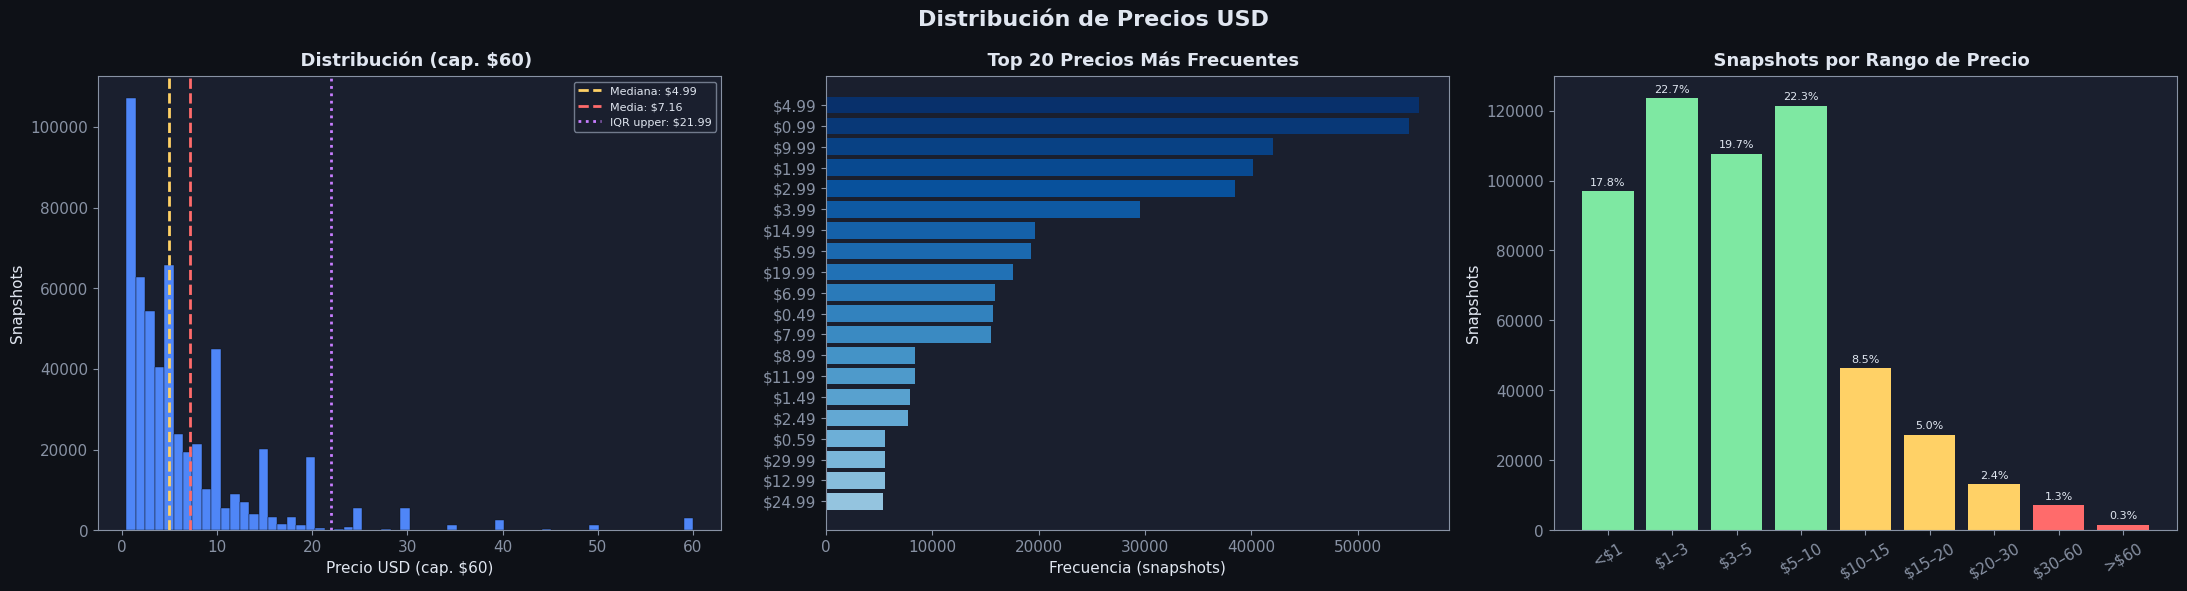

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Distribución de Precios USD', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
ax.hist(usd.clip(upper=60), bins=60, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3)
ax.axvline(usd.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: ${usd.median():.2f}')
ax.axvline(usd.mean(), color=ACCENT3, linewidth=2, linestyle='--',
           label=f'Media: ${usd.mean():.2f}')
ax.axvline(upper_iqr, color=ACCENT5, linewidth=2, linestyle=':',
           label=f'IQR upper: ${upper_iqr:.2f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Precio USD (cap. $60)'); ax.set_ylabel('Snapshots')
title_ax(ax, '  Distribución (cap. $60)')

ax = axes[1]
top20p = usd.value_counts().head(20)
cmap_p = plt.cm.Blues(np.linspace(0.4, 1.0, len(top20p)))
ax.barh([f'${p:.2f}' for p in top20p.index[::-1]],
        top20p.values[::-1], color=cmap_p)
ax.set_xlabel('Frecuencia (snapshots)')
title_ax(ax, '  Top 20 Precios Más Frecuentes')

ax = axes[2]
price_bins   = [0, 1, 3, 5, 10, 15, 20, 30, 60, 1000]
price_labels = ['<$1','$1–3','$3–5','$5–10','$10–15','$15–20','$20–30','$30–60','>$60']
usd_buckets = pd.cut(usd, bins=price_bins, labels=price_labels)
bc = usd_buckets.value_counts().sort_index()
colors_p = [ACCENT2 if i < 4 else ACCENT4 if i < 7 else ACCENT3 for i in range(len(bc))]
ax.bar(bc.index.astype(str), bc.values, color=colors_p)
for i, v in enumerate(bc.values):
    ax.text(i, v + len(usd)*0.003, f'{v/len(usd)*100:.1f}%',
            ha='center', fontsize=8, color=TEXT)
ax.tick_params(axis='x', rotation=30); ax.set_ylabel('Snapshots')
title_ax(ax, '  Snapshots por Rango de Precio')

plt.tight_layout()
plt.show()

---
##  Análisis Temporal — Variación de Precios

###  Hallazgos 
  
- El precio mediano aumenta claramente durante el período:
  - $3.89 el 28-nov
  - $3.74 entre 30-nov y 4-dic
  - $4.99 desde 6-dic en adelante

  Este salto coincide con el fin de una campaña de descuentos, consistente con el cierre del Autumn Sale / Black Friday de Steam, que suele terminar a inicios de diciembre.

- De los 77,941 juegos con precio registrado,  
  43,955 (56.4%) cambian de precio al menos una vez durante el período, mientras 33,985 (43.6%) mantienen un precio constante.

- Comparando el primer y último snapshot, 39,876 juegos cambian de precio:
  - 1,570 bajan de precio (nuevos descuentos)
  - 38,306 suben de precio (fin de descuentos)

  Esto confirma un efecto de reversión de ofertas típico tras eventos de ventas masivas.

- Los mayores descuentos observados alcanzan hasta −98%, lo cual es consistente con promociones extremas o liquidaciones en la plataforma.



In [9]:
df_main = df[df['date_acquired'] <= pd.Timestamp('2024-12-10')].copy()

by_date = df_main.groupby('date_acquired')['usd'].agg(['median','mean','count']).reset_index()
by_date.columns = ['date','median_usd','mean_usd','n_priced']
print("Precio USD por snapshot:")
display(by_date)
print()

price_var = df_main[df_main['usd'].notna()].groupby('gameid')['usd'].nunique()
print(f"Juegos con precio constante (1 valor) : {(price_var == 1).sum():,}  ({(price_var == 1).mean()*100:.1f}%)")
print(f"Juegos con precio variable (>1 valor) : {(price_var > 1).sum():,}  ({(price_var > 1).mean()*100:.1f}%)")
print()

pivot = (df_main[df_main['usd'].notna()]
         .groupby(['gameid','date_acquired'])['usd'].first()
         .unstack('date_acquired'))
first_snap = pivot.iloc[:, 0]
last_snap  = pivot.iloc[:, -1]
both = pd.concat([first_snap, last_snap], axis=1).dropna()
both.columns = ['price_first', 'price_last']
both['pct_change'] = (both['price_last'] - both['price_first']) / both['price_first'] * 100
changed = both[both['pct_change'] != 0]

print(f"Juegos con precio diferente (primer vs último snapshot): {len(changed):,}")
print(f"  Bajaron (descuento)  : {(changed['pct_change'] < 0).sum():,}")
print(f"  Subieron (fin oferta): {(changed['pct_change'] > 0).sum():,}")
print()
print("Top 10 mayores descuentos:")
display(changed.nsmallest(10, 'pct_change')[['price_first','price_last','pct_change']].round(2))

Precio USD por snapshot:


,date,median_usd,mean_usd,n_priced
0,2024-11-28,3.89,5.953505,77934
1,2024-11-30,3.74,5.939222,77921
2,2024-12-02,3.74,5.933558,77922
3,2024-12-04,3.74,5.938351,77923
4,2024-12-06,4.99,8.906552,77913
5,2024-12-08,4.99,8.840467,77899
6,2024-12-10,4.99,8.602333,77834



Juegos con precio constante (1 valor) : 33,985  (43.6%)
Juegos con precio variable (>1 valor) : 43,955  (56.4%)

Juegos con precio diferente (primer vs último snapshot): 39,876
  Bajaron (descuento)  : 1,570
  Subieron (fin oferta): 38,306

Top 10 mayores descuentos:


,price_first,price_last,pct_change
gameid,,,
3204840,39.99,0.49,-98.77
3225930,29.99,0.49,-98.37
595440,29.99,1.49,-95.03
567280,39.99,1.99,-95.02
567290,39.99,1.99,-95.02
583760,39.99,1.99,-95.02
1414850,49.99,2.49,-95.02
3214800,199.99,9.99,-95.00
3214810,199.99,9.99,-95.00


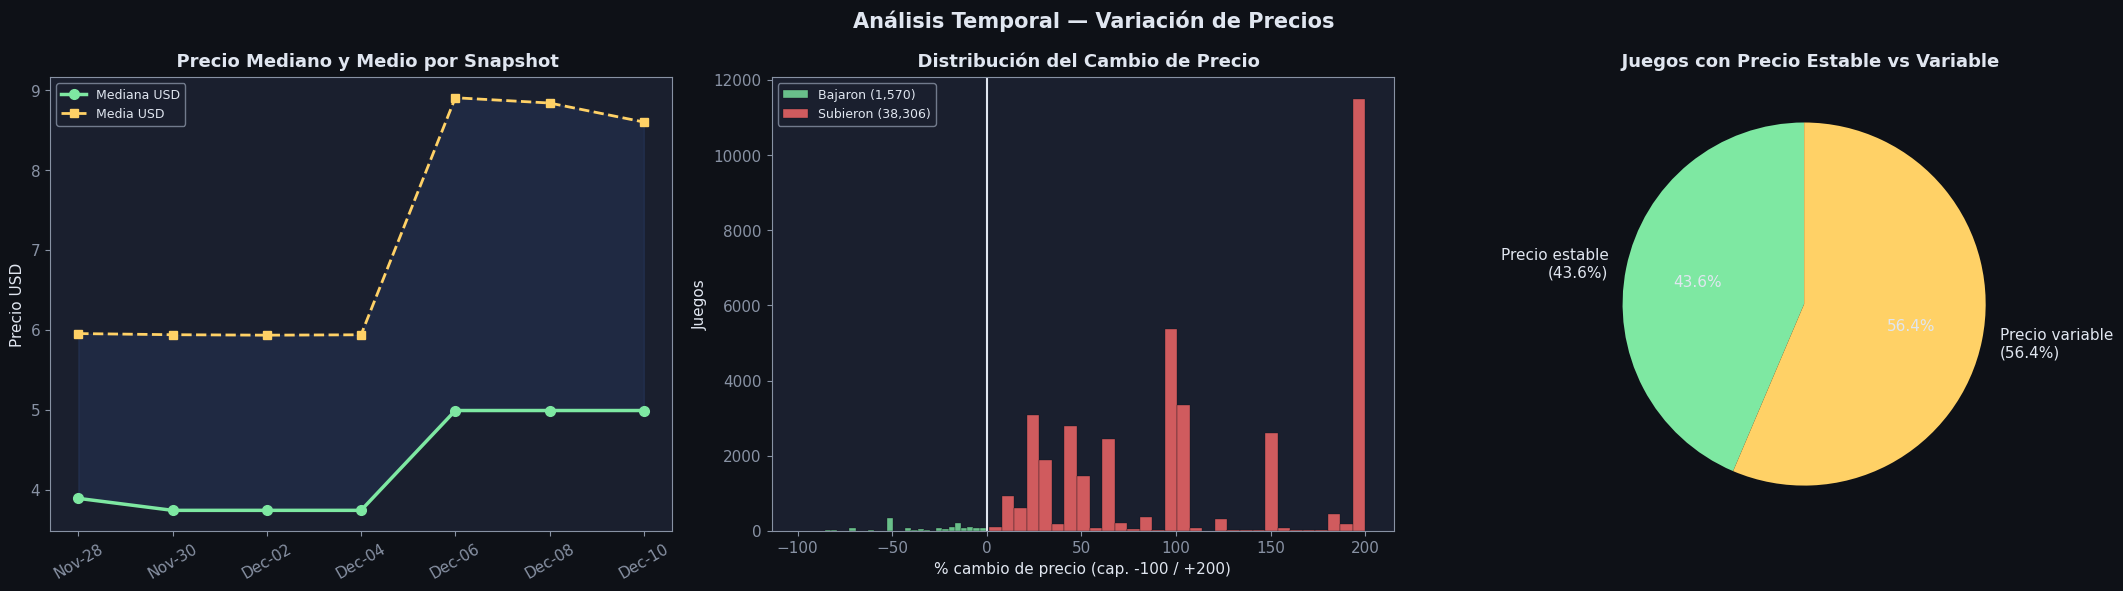

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis Temporal — Variación de Precios', fontsize=15,
             fontweight='bold', color=TEXT)

dates_main = by_date[by_date['n_priced'] > 1000]

ax = axes[0]
x_dates = dates_main['date'].dt.strftime('%b-%d')
ax.plot(x_dates, dates_main['median_usd'], color=ACCENT2, marker='o',
        linewidth=2.5, markersize=7, label='Mediana USD')
ax.plot(x_dates, dates_main['mean_usd'],   color=ACCENT4, marker='s',
        linewidth=2, linestyle='--', markersize=6, label='Media USD')
ax.fill_between(range(len(dates_main)),
                dates_main['median_usd'].values, dates_main['mean_usd'].values,
                alpha=0.1, color=ACCENT1)
ax.tick_params(axis='x', rotation=30); ax.set_ylabel('Precio USD')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Precio Mediano y Medio por Snapshot')

ax = axes[1]
clipped_chg = changed['pct_change'].clip(-100, 200)
ax.hist(clipped_chg[clipped_chg < 0],  bins=30, color=ACCENT2, alpha=0.8,
        edgecolor=DARK_BG, linewidth=0.3, label=f'Bajaron ({(changed["pct_change"]<0).sum():,})')
ax.hist(clipped_chg[clipped_chg > 0],  bins=30, color=ACCENT3, alpha=0.8,
        edgecolor=DARK_BG, linewidth=0.3, label=f'Subieron ({(changed["pct_change"]>0).sum():,})')
ax.axvline(0, color=TEXT, linewidth=1.5, linestyle='-')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('% cambio de precio (cap. -100 / +200)'); ax.set_ylabel('Juegos')
title_ax(ax, '  Distribución del Cambio de Precio')

ax = axes[2]
ax.pie([(price_var == 1).sum(), (price_var > 1).sum()],
       labels=[f'Precio estable\n({(price_var==1).mean()*100:.1f}%)',
               f'Precio variable\n({(price_var>1).mean()*100:.1f}%)'],
       colors=[ACCENT2, ACCENT4], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Juegos con Precio Estable vs Variable')

plt.tight_layout()
plt.show()

---
##  Análisis de Monedas — Localización de Precios

###  Hallazgos

- Steam no utiliza una conversión directa de divisas para fijar precios. Los tipos de cambio implícitos muestran una alta variabilidad, especialmente en JPY (std = 68.3) y RUB (std = 181.1), lo que indica que los publishers ajustan precios por región en lugar de seguir el mercado cambiario.

- La mediana del ratio EUR/USD es 0.987, muy cercana a la paridad. Esto sugiere que muchos juegos utilizan pricing simétrico (ej. `$4.99 → €4.99`), una práctica común en juegos indie para simplificar la estructura de precios.

- Los precios en RUB presentan outliers extremos (máx = 33,444 RUB por USD). Esto probablemente refleja:
  - precios no actualizados tras las sanciones económicas a Rusia (2022)
  - errores de catálogo o bundles con pricing atípico.

- JPY también muestra gran dispersión (máx = 13,654 JPY por USD) comparado con la tasa real (~150 JPY/USD). Esto indica localización agresiva de precios o bundles especiales en el mercado japonés.

### Disponibilidad regional (snapshot más reciente, juegos con USD)

- **EUR:** 76.6% de juegos disponibles  
- **GBP:** 99.9%  
- **JPY:** 99.6%  
- **RUB:** 97.1%

Esto confirma que **Europa tiene la mayor proporción de juegos sin precio localizado**, lo que coincide con el análisis previo de valores faltantes donde EUR tenía muchos más NaN que USD.



In [11]:
has_all = df.dropna(subset=['usd','eur','gbp','jpy','rub'])
has_all = has_all[has_all['usd'] > 0].copy()

for curr in ['eur','gbp','jpy','rub']:
    has_all[f'rate_{curr}'] = has_all[curr] / has_all['usd']

print(f"Snapshots con todas las monedas: {len(has_all):,}")
print()
print("Tipos de cambio implícitos (moneda / USD):")
rate_cols = [f'rate_{c}' for c in ['eur','gbp','jpy','rub']]
display(has_all[rate_cols].describe(percentiles=[.1,.25,.5,.75,.90,.99]).round(4))
print()

df_snap1 = df[df['date_acquired'] == df['date_acquired'].min()]
priced   = df_snap1[df_snap1['usd'].notna()]
print("Disponibilidad regional (snapshot más reciente, juegos con USD):")
for curr in ['eur','gbp','jpy','rub']:
    pct = priced[curr].notna().mean() * 100
    print(f"  {curr.upper()}: {pct:.1f}% de juegos con precio")

Snapshots con todas las monedas: 404,532

Tipos de cambio implícitos (moneda / USD):


,rate_eur,rate_gbp,rate_jpy,rate_rub
count,404532.0000,404532.0000,404532.0000,404532.0000
mean,0.9471,0.8266,113.3706,38.1167
std,0.0977,0.0809,68.3063,181.0955
min,0.1583,0.1502,6.6711,0.0000
10%,0.7996,0.7243,101.0463,24.1034
25%,0.8420,0.7980,103.0151,26.6533
50%,0.9867,0.8382,115.1439,38.5385
75%,1.0000,0.8531,118.0905,41.2060
90%,1.0000,0.8980,121.2121,42.4242
99%,1.0000,1.0000,150.2504,81.6054



Disponibilidad regional (snapshot más reciente, juegos con USD):
  EUR: 76.6% de juegos con precio
  GBP: 99.9% de juegos con precio
  JPY: 99.6% de juegos con precio
  RUB: 97.1% de juegos con precio


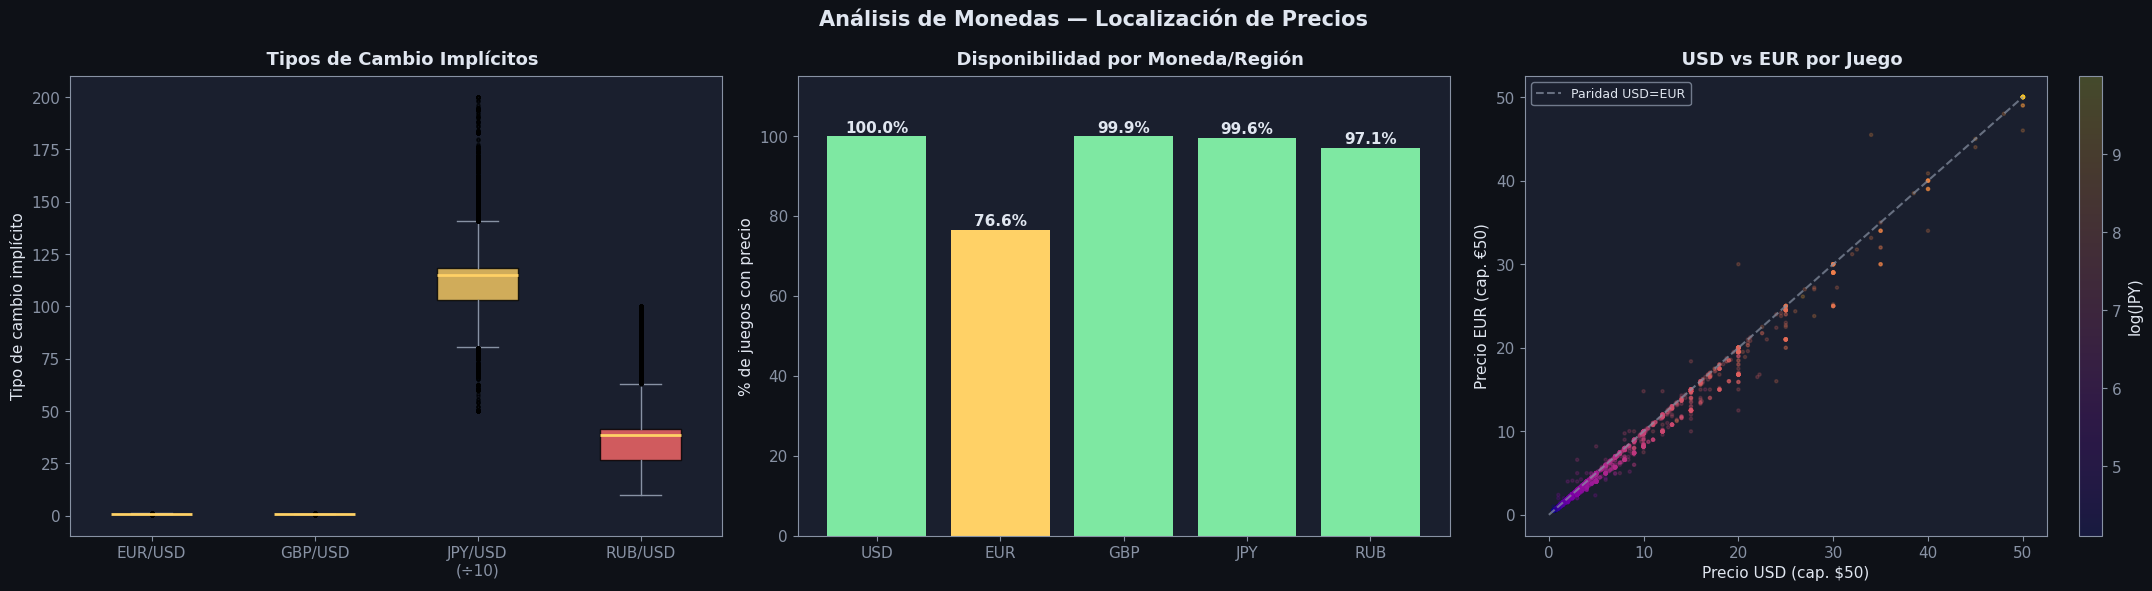

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis de Monedas — Localización de Precios', fontsize=15,
             fontweight='bold', color=TEXT)

curr_colors = [ACCENT2, ACCENT1, ACCENT4, ACCENT3]

ax = axes[0]
caps = {'rate_eur': (0.5, 1.5), 'rate_gbp': (0.4, 1.2),
        'rate_jpy': (50, 200), 'rate_rub': (10, 100)}
data_box = [has_all[col].clip(*caps[col]).dropna().values for col in rate_cols]
bp = ax.boxplot(data_box, vert=True, patch_artist=True, widths=0.5,
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', alpha=0.1, markersize=2))
for patch, color in zip(bp['boxes'], curr_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(['EUR/USD','GBP/USD','JPY/USD\n(÷10)','RUB/USD'])

ax.set_ylabel('Tipo de cambio implícito')
title_ax(ax, '  Tipos de Cambio Implícitos')


ax = axes[1]
avail = {curr.upper(): priced[curr].notna().mean()*100 for curr in ['usd','eur','gbp','jpy','rub']}
colors_av = [ACCENT2 if v > 90 else ACCENT4 if v > 75 else ACCENT3 for v in avail.values()]
bars_av = ax.bar(list(avail.keys()), list(avail.values()), color=colors_av)
for bar, val in zip(bars_av, avail.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11, color=TEXT, fontweight='bold')
ax.set_ylabel('% de juegos con precio'); ax.set_ylim(0, 115)
title_ax(ax, '  Disponibilidad por Moneda/Región')

ax = axes[2]
sample_scatter = has_all.sample(min(5000, len(has_all)), random_state=42)
sc = ax.scatter(sample_scatter['usd'].clip(upper=50),
                sample_scatter['eur'].clip(upper=50),
                alpha=0.2, s=5, c=np.log1p(sample_scatter['jpy']),
                cmap='plasma')

lim = 50
ax.plot([0, lim], [0, lim], color=MUTED, linewidth=1.5, linestyle='--',
        label='Paridad USD=EUR', alpha=0.7)
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
plt.colorbar(sc, ax=ax, label='log(JPY)')
ax.set_xlabel('Precio USD (cap. $50)'); ax.set_ylabel('Precio EUR (cap. €50)')
title_ax(ax, '  USD vs EUR por Juego')

plt.tight_layout()
plt.show()

---
##  Outliers: Precios Extremos

###  Hallazgos

- Una pequeña fracción del catálogo corresponde a **precios muy altos**, pero la mayoría siguen rangos típicos del mercado. En la segmentación por precios (juegos únicos):

  - budget ($2–$10): 36.5% segmento dominante del catálogo
  - mid ($10–$30): 21.7%
  - micro (<$2): 16.6%
  - premium ($30–$60): 4.2%
  - AAA (>$60): 0.6%
  - special (>$200): 0.2%

- Los juegos extremadamente caros son muy raros:
  - 9 juegos tienen precio > $200
  - 2 juegos tienen precio $999.98

- El precio de $999.98 aparece de forma consistente en todos los snapshots, lo que indica que no es un spike temporal. Es probable que corresponda a:
  - bundles muy grandes
  - asset packs para desarrolladores
  - o productos especiales en la plataforma.

- En total, 20.2% de juegos nunca tienen precio registrado, lo que coincide con el análisis previo de valores faltantes y sugiere juegos free-to-play o sin precio activo.




In [13]:
latest_price = (df[df['usd'].notna()]
                .sort_values('date_acquired')
                .groupby('gameid')['usd'].last())

def price_tier(p):
    if   pd.isna(p):   return 'free_or_unknown'  
    elif p < 1:        return 'micro'             
    elif p < 5:        return 'budget'           
    elif p < 15:       return 'mid'               
    elif p < 30:       return 'premium'           
    elif p <= 60:      return 'aaa'               
    else:              return 'special'        

df['price_tier'] = df['usd'].map(price_tier)
df.loc[~df['has_price'], 'price_tier'] = 'free_or_unknown'
df['usd_log'] = np.log1p(df['usd'])

tier_order = ['free_or_unknown','micro','budget','mid','premium','aaa','special']
tier_counts = df.drop_duplicates('gameid')['price_tier'].value_counts().reindex(tier_order, fill_value=0)
print("Distribución de price_tier (juegos únicos):")
for t, n in tier_counts.items():
    total_games = len(df['gameid'].unique())
    print(f"  {t:<18}: {n:,}  ({n/total_games*100:.1f}%)")
print()
print(f"Juegos con precio > $200: {(latest_price > 200).sum()}")
print(f"Juegos con precio = $999.98: {(latest_price == 999.98).sum()}")

Distribución de price_tier (juegos únicos):
  free_or_unknown   : 19,777  (20.2%)
  micro             : 16,202  (16.6%)
  budget            : 35,663  (36.5%)
  mid               : 21,186  (21.7%)
  premium           : 4,075  (4.2%)
  aaa               : 627  (0.6%)
  special           : 183  (0.2%)

Juegos con precio > $200: 9
Juegos con precio = $999.98: 2


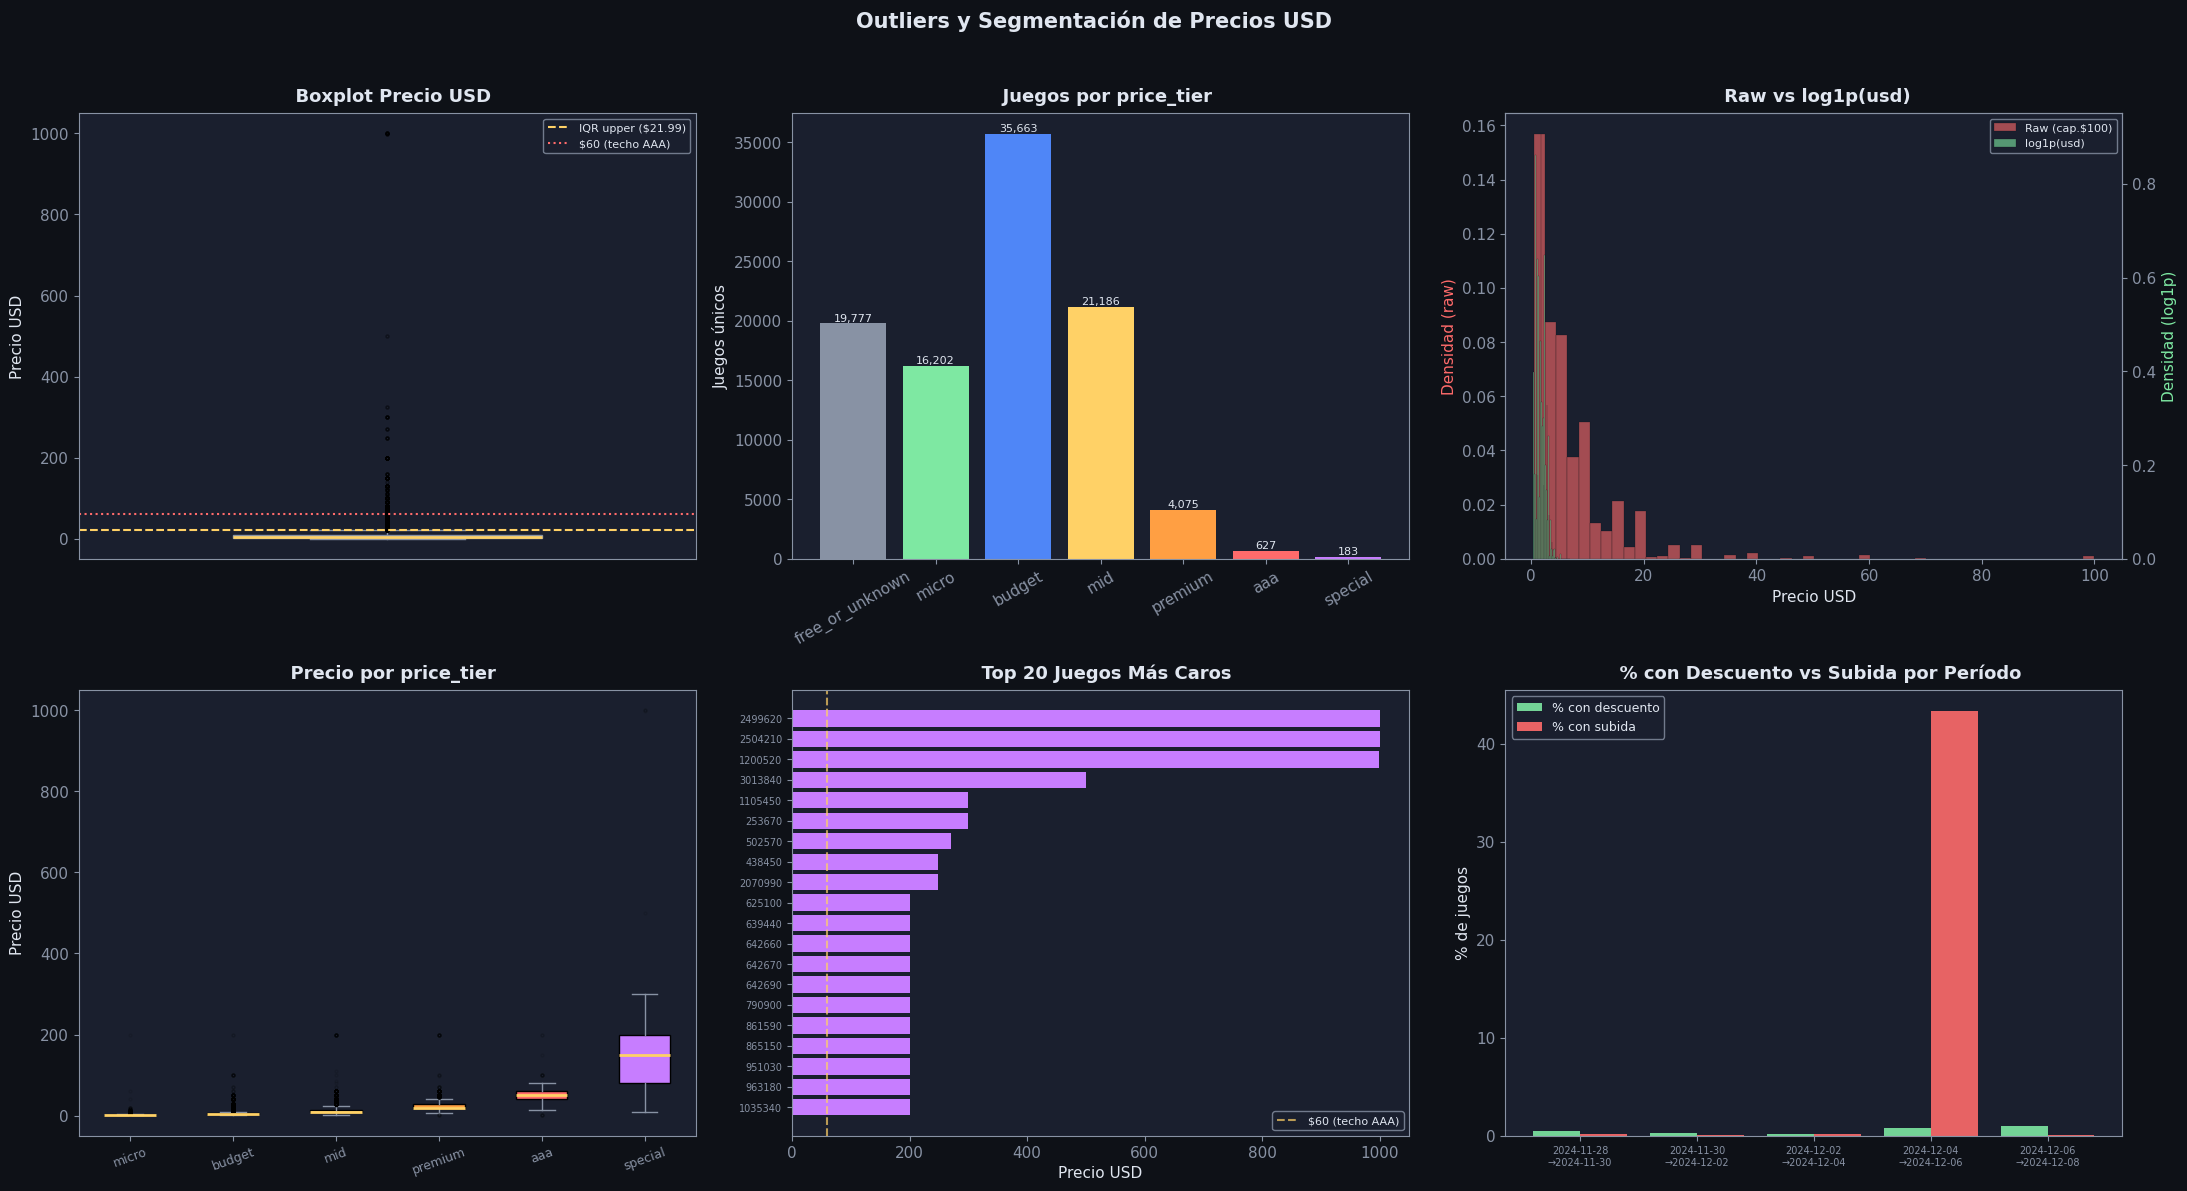

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Outliers y Segmentación de Precios USD', fontsize=15,
             fontweight='bold', color=TEXT, y=0.99)

tier_colors_map = {
    'free_or_unknown': MUTED, 'micro': ACCENT2, 'budget': ACCENT1,
    'mid': ACCENT4, 'premium': '#ff9f43', 'aaa': ACCENT3, 'special': ACCENT5
}


ax = axes[0, 0]
bp = ax.boxplot(usd.values, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=ACCENT1, color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=ACCENT3, alpha=0.15, markersize=2))
ax.axhline(upper_iqr, color=ACCENT4, linewidth=1.5, linestyle='--',
           label=f'IQR upper (${upper_iqr:.2f})')
ax.axhline(60, color=ACCENT3, linewidth=1.5, linestyle=':',
           label='$60 (techo AAA)')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Precio USD'); ax.set_xticks([])
title_ax(ax, '  Boxplot Precio USD')


ax = axes[0, 1]
colors_t = [tier_colors_map[t] for t in tier_counts.index]
bars_t = ax.bar(tier_counts.index, tier_counts.values, color=colors_t)
for bar, val in zip(bars_t, tier_counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', fontsize=8, color=TEXT)
ax.tick_params(axis='x', rotation=30); ax.set_ylabel('Juegos únicos')
title_ax(ax, '  Juegos por price_tier')


ax = axes[0, 2]
ax.hist(usd.clip(upper=100), bins=50, color=ACCENT3, alpha=0.6,
        edgecolor=DARK_BG, linewidth=0.3, label='Raw (cap.$100)', density=True)
ax2 = ax.twinx()
ax2.hist(np.log1p(usd), bins=50, color=ACCENT2, alpha=0.6,
         edgecolor=DARK_BG, linewidth=0.3, label='log1p(usd)', density=True)
ax2.tick_params(colors=MUTED)
ax.set_xlabel('Precio USD')
ax.set_ylabel('Densidad (raw)', color=ACCENT3)
ax2.set_ylabel('Densidad (log1p)', color=ACCENT2)
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, ' Raw vs log1p(usd)')

ax = axes[1, 0]

tiers_with_price = [t for t in tier_order if t not in ('free_or_unknown',)]


df_unique = df.drop_duplicates('gameid')[['gameid','price_tier']].merge(
    latest_price.reset_index(), on='gameid', how='left'
)

data_tiers = [
    df_unique[df_unique['price_tier']==t]['usd'].dropna().values
    for t in tiers_with_price
]

bp2 = ax.boxplot(
    [d for d in data_tiers if len(d) > 0],
    vert=True,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color=ACCENT4, linewidth=2),
    whiskerprops=dict(color=MUTED),
    capprops=dict(color=MUTED),
    flierprops=dict(marker='o', alpha=0.1, markersize=2)
)

valid_tiers = [t for t, d in zip(tiers_with_price, data_tiers) if len(d) > 0]

for patch, t in zip(bp2['boxes'], valid_tiers):
    patch.set_facecolor(tier_colors_map[t])

ax.set_xticklabels(valid_tiers, rotation=20, fontsize=9)
ax.set_ylabel('Precio USD')

title_ax(ax, '  Precio por price_tier')

ax = axes[1, 1]
top20_p = latest_price.nlargest(20)
colors_top = [ACCENT5 if v >= 100 else ACCENT3 for v in top20_p.values]
ax.barh(top20_p.index.astype(str)[::-1], top20_p.values[::-1], color=colors_top[::-1])
ax.axvline(60, color=ACCENT4, linewidth=1.5, linestyle='--',
           label='$60 (techo AAA)', alpha=0.7)
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Precio USD')
ax.tick_params(axis='y', labelsize=7)
title_ax(ax, '  Top 20 Juegos Más Caros')

ax = axes[1, 2]
dates_sorted = sorted(df['date_acquired'].dropna().unique())
discount_pcts = []
for i in range(1, min(6, len(dates_sorted))):
    d_prev = dates_sorted[i-1]
    d_curr = dates_sorted[i]
    prev_p = df[df['date_acquired']==d_prev].set_index('gameid')['usd']
    curr_p = df[df['date_acquired']==d_curr].set_index('gameid')['usd']
    common = prev_p.index.intersection(curr_p.index)
    if len(common) > 0:
        ratio = (curr_p[common] < prev_p[common]).mean() * 100
        discount_pcts.append({'period': f"{str(d_prev)[:10]}\n→{str(d_curr)[:10]}",
                               'pct_with_discount': ratio,
                               'pct_price_increase': (curr_p[common] > prev_p[common]).mean()*100})
df_disc = pd.DataFrame(discount_pcts)
if len(df_disc) > 0:
    x = range(len(df_disc))
    ax.bar([i - 0.2 for i in x], df_disc['pct_with_discount'],  width=0.4,
           color=ACCENT2, label='% con descuento', alpha=0.9)
    ax.bar([i + 0.2 for i in x], df_disc['pct_price_increase'], width=0.4,
           color=ACCENT3, label='% con subida', alpha=0.9)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_disc['period'], fontsize=7)
    ax.set_ylabel('% de juegos')
    ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  % con Descuento vs Subida por Período')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Dataset limpio final

In [15]:
df['usd_log'] = np.log1p(df['usd'])

print("═" * 58)
print("  RESUMEN FINAL — prices")
print("═" * 58)
print(f"  Filas originales             : {df_raw.shape[0]:>10,}")
print(f"  Filas finales (limpias)      : {len(df):>10,}")
print(f"  Eliminadas (fecha anómala)   : {df_raw.shape[0] - len(df):>10,}")
print(f"  Juegos únicos                : {df['gameid'].nunique():>10,}")
print(f"  Snapshots (fechas válidas)   : {df['date_acquired'].nunique():>10,}")
print(f"  Rango temporal               :  {df['date_acquired'].min().date()} → {df['date_acquired'].max().date()}")
print()
print(f"  Con precio USD               : {df['usd'].notna().sum():>10,} snapshots ({df['gameid'][df['usd'].notna()].nunique():,} juegos)")
print(f"  Sin precio USD (never)       : {len(never_priced_ids):>10,} juegos únicos")
print(f"  Sin EUR (no disponible EU)   : {df['no_eur_region'].sum():>10,} snapshots")
print(f"  Outliers precio >$60         : {(df['usd']>60).sum():>10,} snapshots")
print("═" * 58)
print()
print("Columnas disponibles:")
print(df.dtypes)
df.head(3)

══════════════════════════════════════════════════════════
  RESUMEN FINAL — prices
══════════════════════════════════════════════════════════
  Filas originales             :  4,414,273
  Filas finales (limpias)      :    683,883
  Eliminadas (fecha anómala)   :  3,730,390
  Juegos únicos                :     97,713
  Snapshots (fechas válidas)   :          7
  Rango temporal               :  2024-11-28 → 2024-12-10

  Con precio USD               :    545,346 snapshots (77,940 juegos)
  Sin precio USD (never)       :     19,773 juegos únicos
  Sin EUR (no disponible EU)   :    125,625 snapshots
  Outliers precio >$60         :      1,600 snapshots
══════════════════════════════════════════════════════════

Columnas disponibles:
gameid                    int64
usd                     float64
eur                     float64
gbp                     float64
jpy                     float64
rub                     float64
date_acquired    datetime64[ns]
has_price                  bool
no_e

,gameid,usd,eur,gbp,jpy,rub,date_acquired,has_price,no_eur_region,price_tier,usd_log
0,3281560,NaN,NaN,NaN,NaN,NaN,2024-11-28,False,False,free_or_unknown,NaN
1,3280930,NaN,NaN,NaN,NaN,NaN,2024-11-28,False,False,free_or_unknown,NaN
2,3280770,NaN,NaN,NaN,NaN,NaN,2024-11-28,False,False,free_or_unknown,NaN


---
## Exportar dataset limpio


**Archivo generado:**
- `prices_per_game.csv` — una fila por juego con el **precio más reciente**: `gameid`, `usd_latest`, `usd_log`, `price_tier`, `has_price`, `no_eur_region`


In [16]:
latest = (
    df[df['usd'].notna()]
    .sort_values('date_acquired')
    .groupby('gameid')
    .last()
    .reset_index()
    [['gameid','usd','eur','gbp','jpy','rub','date_acquired',
      'has_price','no_eur_region','price_tier','usd_log']]
    .rename(columns={'usd': 'usd_latest', 'date_acquired': 'price_snapshot_date'})
)


all_gameids = df['gameid'].unique()
missing_games = pd.DataFrame({'gameid': [g for g in all_gameids if g not in latest['gameid'].values]})
missing_games['has_price']  = False
missing_games['price_tier'] = 'free_or_unknown'

prices_per_game = pd.concat([latest, missing_games], ignore_index=True)
prices_per_game['has_price'] = prices_per_game['has_price'].fillna(True)

prices_per_game.to_csv('Datos/prices_per_game.csv', index=False)

print(f'prices_per_game.csv : {len(prices_per_game):,} juegos')
print(f'  Con precio         : {prices_per_game["has_price"].sum():,}')
print(f'  Sin precio (F2P?)  : {(~prices_per_game["has_price"]).sum():,}')
prices_per_game.head(3)


prices_per_game.csv : 97,713 juegos
  Con precio         : 77,940
  Sin precio (F2P?)  : 19,773


,gameid,usd_latest,eur,gbp,jpy,rub,price_snapshot_date,has_price,no_eur_region,price_tier,usd_log
0,10,9.99,8.19,7.19,1010.0,259.0,2024-12-10,True,False,mid,2.396986
1,20,4.99,4.99,4.29,580.0,200.0,2024-12-10,True,False,budget,1.790091
2,30,4.99,4.99,4.29,580.0,200.0,2024-12-10,True,False,budget,1.790091


---
##  Conclusiones

### Próximos pasos
- **Feature para clasificación:** usar `usd_log` (numérica) y `price_tier` (categórica) como features del juego.
- **Feature de descuento:** con el dataset completo, calcular `pct_discount = (price_max - price_min) / price_max` por juego como señal de si estuvo en oferta.
- **Flag F2P — responsabilidad de `prices`:** el cruce `has_price=False` con `purchased_games` (si `n_owners_public > 0` entonces `is_f2p = True`) debe realizarse en el notebook de **feature engineering de juegos**, no aquí. Esta tabla provee `has_price`; `purchased_games` provee `n_owners_public`. La decisión final vive en el join.
- **Ignorar RUB para el modelo:** alta varianza y restricciones geopolíticas lo hacen poco informativo como feature directa.
- **Disponibilidad regional como feature:** `no_eur_region` (bool) puede ser un predictor de alcance comercial del juego.